# Interpreting ViT-B/32 Attention Heads: SAM vs M-SAM

Mechanistic analysis of how SAM and M-SAM training shapes attention head behaviour in ViT-B/32 fine-tuned on CIFAR-10.

**Checkpoints**: `results/vit_b_32/experiments/reparam/vit_b_32/checkpoints/` (alpha=5.0 reparam, seeds 40/41/42)

**Analyses**:
1. CLS→patch attention spatial maps
2. Per-head entropy (diffuse vs focused attention)
3. Attention rollout (Abnar & Zuidema 2020)
4. Head diversity per layer (inter-head cosine similarity)
5. Cross-seed robustness (mean ± std across seeds 40/41/42)


In [1]:
import os, sys
from pathlib import Path

# ── repo root on sys.path ────────────────────────────────────────────────────
ROOT = Path(__file__).resolve().parents[2] if "__file__" in dir() else Path("/Users/manavdahra/workspace/sam-opt-research")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from contextlib import contextmanager
import pickle

# ── paths ────────────────────────────────────────────────────────────────────
CKPT_DIR = ROOT / "results/vit_b_32/experiments/reparam/vit_b_32/checkpoints"
DATA_DIR  = ROOT / "data/cifar-10-batches-py"

SEEDS     = [40, 41, 42]
RHO       = 0.05
ALPHA     = 5.0

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                       else "cuda" if torch.cuda.is_available()
                       else "cpu")
print(f"Device: {DEVICE}")
print(f"Checkpoint dir exists: {CKPT_DIR.exists()}")


Device: mps
Checkpoint dir exists: True


## 1. Load Models

In [2]:
from src.models.vit import get_vit_b_32


def load_vit_checkpoint(ckpt_path: Path, device) -> torch.nn.Module:
    model = get_vit_b_32(num_classes=10, pretrained=False)
    state = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model


def ckpt_path(opt: str, rho: float, alpha: float, seed: int) -> Path:
    return CKPT_DIR / f"{opt}_rho{rho}_alpha{alpha}_seed{seed}.pt"


# Load single-seed models for initial visualisations (seed=40)
model_sam  = load_vit_checkpoint(ckpt_path("sam",  RHO, ALPHA, 40), DEVICE)
model_msam = load_vit_checkpoint(ckpt_path("msam", RHO, ALPHA, 40), DEVICE)

print("SAM  model loaded:", sum(p.numel() for p in model_sam.parameters()), "params")
print("MSAM model loaded:", sum(p.numel() for p in model_msam.parameters()), "params")


SAM  model loaded: 87462922 params
MSAM model loaded: 87462922 params


## 2. Load CIFAR-10 Test Images

Batch shape: torch.Size([10, 3, 224, 224])


/var/folders/xw/g9196zkx6890d2h8r_cssrcr0000gn/T/ipykernel_72395/2067652785.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding="bytes")


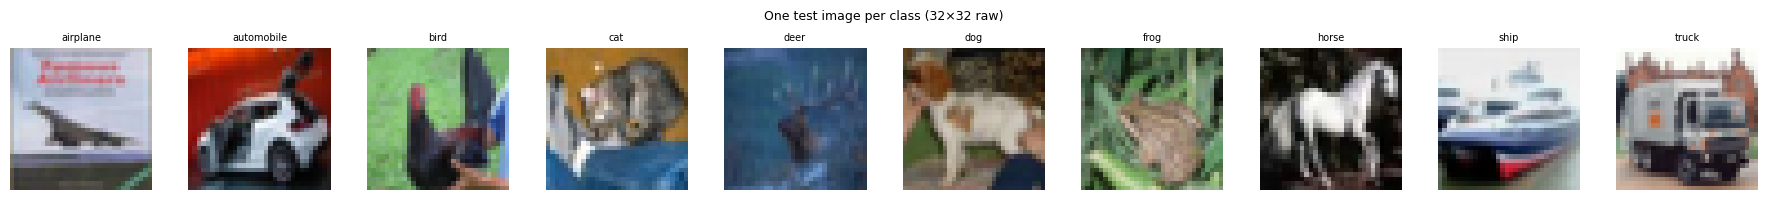

In [3]:
def load_cifar10_test_batch(data_dir: Path):
    """Load raw CIFAR-10 test batch from the binary file."""
    with open(data_dir / "test_batch", "rb") as f:
        d = pickle.load(f, encoding="bytes")
    images = d[b"data"].reshape(-1, 3, 32, 32).astype(np.uint8)  # (10000, 3, 32, 32)
    labels = d[b"labels"]
    return images, labels


# Transform matching ViT training: resize to 224 + CIFAR-10 normalisation
vit_transform = T.Compose([
    T.ToPILImage(),
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

# Inverse transform for display (undo normalisation)
_mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
_std  = torch.tensor(CIFAR10_STD).view(3, 1, 1)

def denorm(t: torch.Tensor) -> np.ndarray:
    """(3,H,W) normalised tensor → (H,W,3) uint8 numpy for imshow."""
    img = (t.cpu() * _std + _mean).clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


raw_images, raw_labels = load_cifar10_test_batch(DATA_DIR)

# Pick the first image of each class (10 images total)
class_images_raw = {}
class_images_tensor = {}
for cls_idx in range(10):
    idx = next(i for i, l in enumerate(raw_labels) if l == cls_idx)
    img_chw = raw_images[idx]                         # (3, 32, 32) uint8
    class_images_raw[cls_idx]    = img_chw
    class_images_tensor[cls_idx] = vit_transform(img_chw.transpose(1, 2, 0))

# Stack into batch tensor (10, 3, 224, 224)
batch = torch.stack([class_images_tensor[c] for c in range(10)]).to(DEVICE)
print("Batch shape:", batch.shape)

# Quick sanity visualisation
fig, axes = plt.subplots(1, 10, figsize=(18, 2))
for c in range(10):
    axes[c].imshow(class_images_raw[c].transpose(1, 2, 0))
    axes[c].set_title(CIFAR10_CLASSES[c], fontsize=7)
    axes[c].axis("off")
plt.suptitle("One test image per class (32×32 raw)", fontsize=9)
plt.tight_layout()
plt.show()


## 3. Attention Extraction

We temporarily monkey-patch each `EncoderBlock.forward` to call `self_attention` with `need_weights=True, average_attn_weights=False`, capturing a tensor of shape `(B, 12_heads, 50_tokens, 50_tokens)` per layer.
Token 0 is the CLS token; tokens 1–49 are the 7×7 patch grid.

In [4]:
@contextmanager
def capture_attention_weights(model: torch.nn.Module):
    """Temporarily patch all EncoderBlocks to return per-head attention weights.

    torchvision ViT calls self_attention with need_weights=False by default.
    We replace each block's forward to call with need_weights=True,
    average_attn_weights=False → shape (B, num_heads, seq_len, seq_len).

    Yields a dict {layer_idx: Tensor} populated after a forward pass.
    """
    store: dict[int, torch.Tensor] = {}
    original_forwards: dict[int, callable] = {}

    for idx, block in enumerate(model.encoder.layers):
        original_forwards[idx] = block.forward

        def _make_patched(layer_idx, blk):
            def patched_forward(inp):
                x = blk.ln_1(inp)
                x_attn, attn_w = blk.self_attention(
                    x, x, x,
                    need_weights=True,
                    average_attn_weights=False,
                )
                # attn_w: (B, num_heads, seq_len, seq_len)
                store[layer_idx] = attn_w.detach().cpu()
                x = blk.dropout(x_attn)
                x = x + inp
                y = blk.ln_2(x)
                y = blk.mlp(y)
                return x + y
            return patched_forward

        block.forward = _make_patched(idx, block)

    try:
        yield store
    finally:
        for idx, block in enumerate(model.encoder.layers):
            block.forward = original_forwards[idx]


def extract_attentions(model: torch.nn.Module, x: torch.Tensor) -> dict[int, torch.Tensor]:
    """Run a forward pass and return {layer_idx: attn_weights (B, H, S, S)}."""
    with torch.no_grad():
        with capture_attention_weights(model) as store:
            _ = model(x)
    return store  # dict of 12 tensors, each (B, 12, 50, 50)


print("Extraction utilities defined.")
print("Sequence length: 1 CLS + 7×7 patches =", 1 + 7 * 7, "tokens")
print("Expected attn shape per layer: (B=10, H=12, S=50, S=50)")


Extraction utilities defined.
Sequence length: 1 CLS + 7×7 patches = 50 tokens
Expected attn shape per layer: (B=10, H=12, S=50, S=50)


In [5]:
# Extract attentions for SAM and MSAM (seed 40, all 10 class images)
attn_sam  = extract_attentions(model_sam,  batch)   # {0..11: (10, 12, 50, 50)}
attn_msam = extract_attentions(model_msam, batch)

print("Layers captured:", sorted(attn_sam.keys()))
print("Shape per layer:", attn_sam[0].shape)  # (10, 12, 50, 50)


Layers captured: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Shape per layer: torch.Size([10, 12, 50, 50])


## 4. CLS → Patch Attention Spatial Maps

For a chosen image, show how each of the 12 heads in every layer attends from the CLS token to
the 7×7 patch grid. Brighter = more attention. Rows = layers, columns = heads.

Plotting CLS attention maps for image: dog


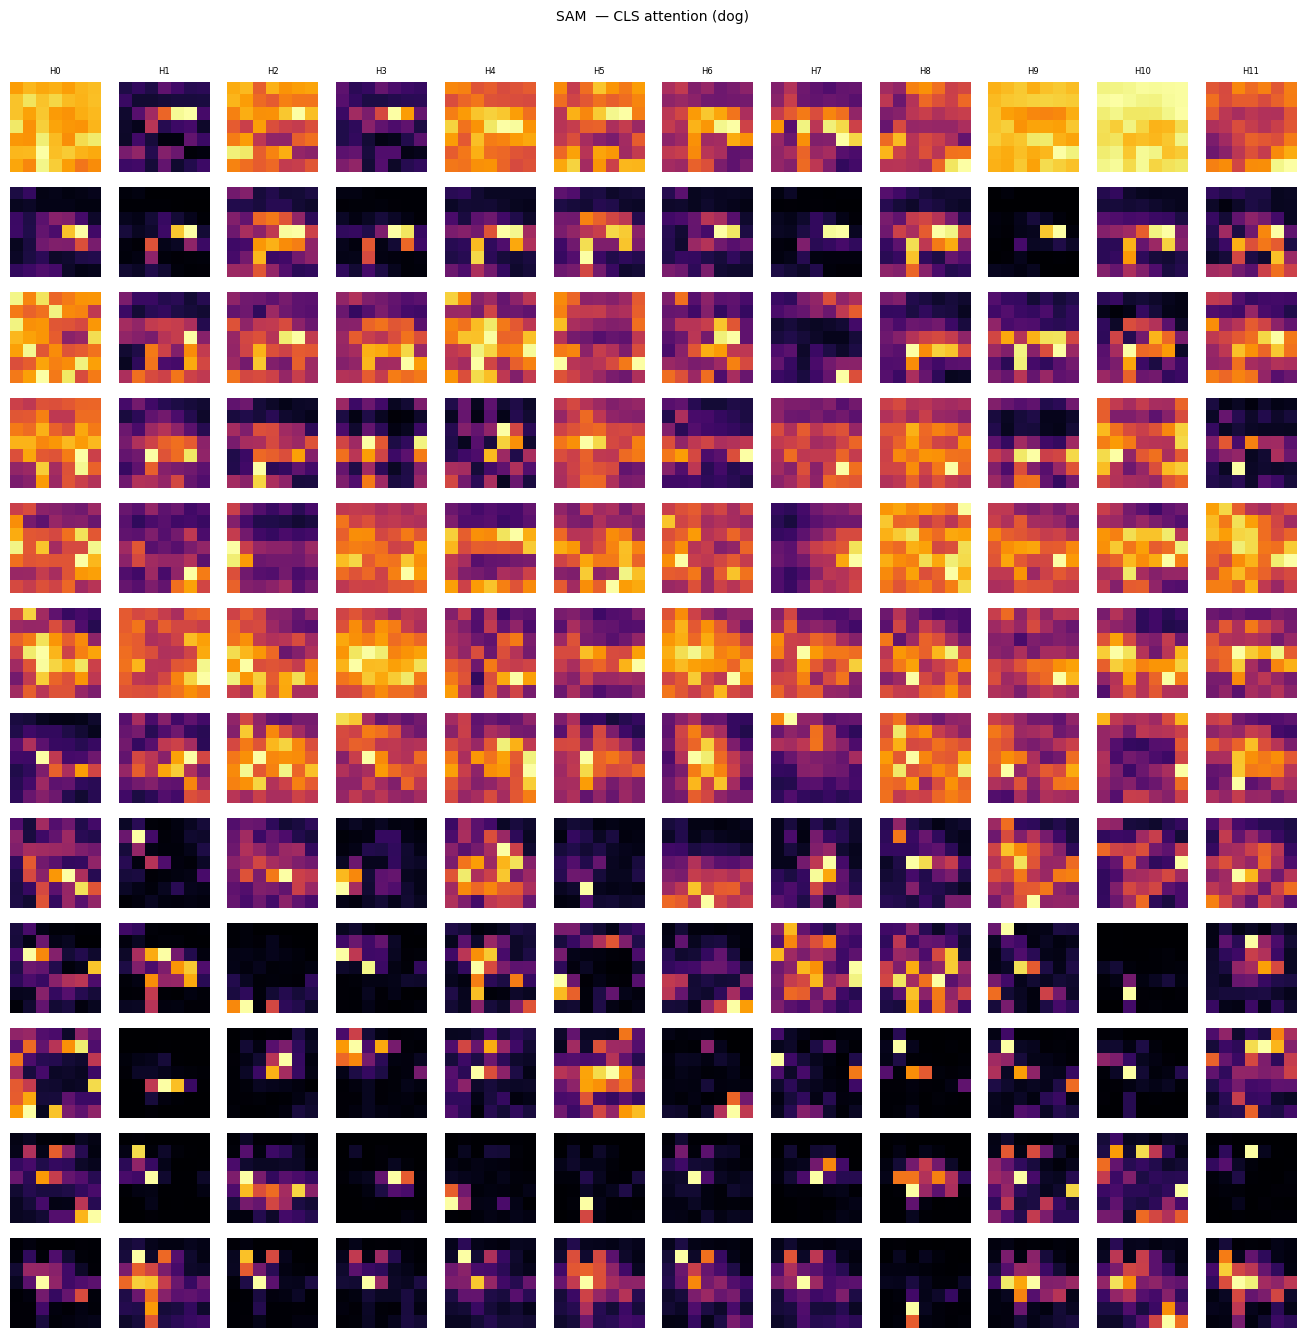

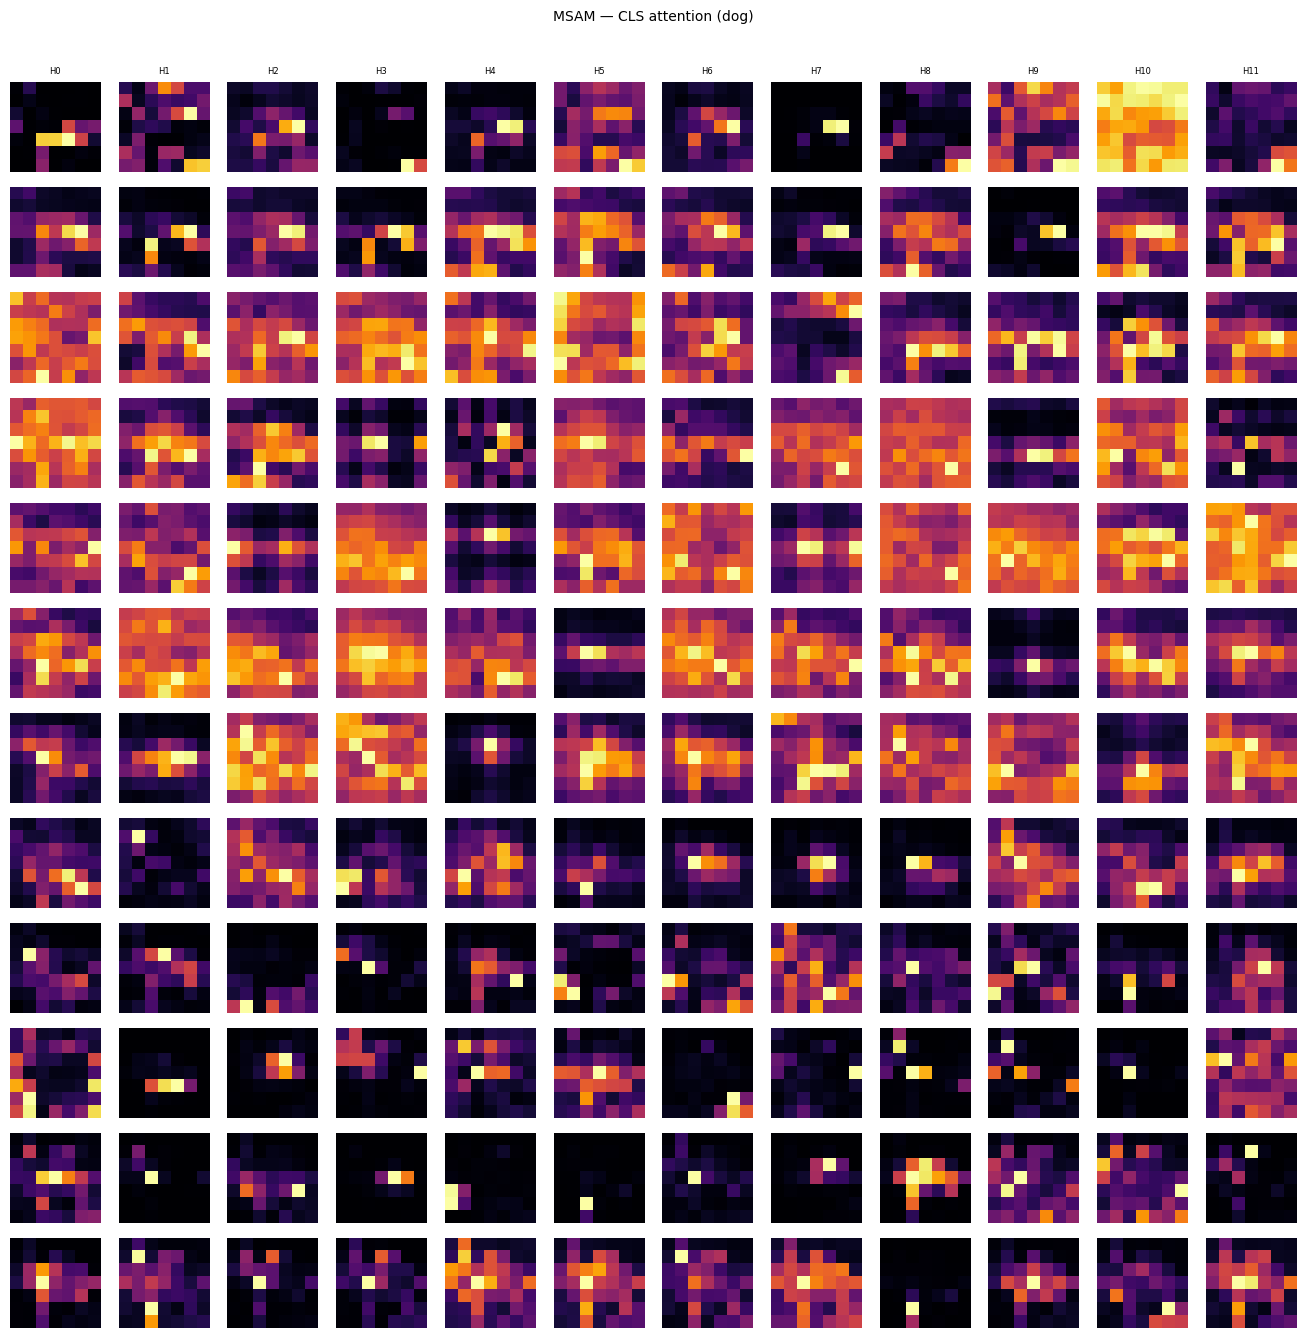

In [6]:
PATCH_GRID = 7   # 7×7 = 49 patches for ViT-B/32 on 224×224
NUM_LAYERS = 12
NUM_HEADS  = 12


def cls_patch_attn(attn_dict: dict, img_idx: int) -> np.ndarray:
    """Return array (num_layers, num_heads, 7, 7) of CLS→patch attention."""
    maps = np.zeros((NUM_LAYERS, NUM_HEADS, PATCH_GRID, PATCH_GRID))
    for layer, weights in attn_dict.items():
        # weights: (B, H, S, S); CLS is token 0, patches are tokens 1..49
        cls_attn = weights[img_idx, :, 0, 1:]  # (H, 49)
        maps[layer] = cls_attn.numpy().reshape(NUM_HEADS, PATCH_GRID, PATCH_GRID)
    return maps


def plot_cls_attn_grid(attn_dict: dict, img_idx: int, title: str, ax_img=None):
    """Plot 12×12 grid of CLS attention maps (rows=layers, cols=heads)."""
    maps = cls_patch_attn(attn_dict, img_idx)  # (12, 12, 7, 7)

    fig, axes = plt.subplots(NUM_LAYERS, NUM_HEADS, figsize=(NUM_HEADS * 1.1, NUM_LAYERS * 1.1))
    for layer in range(NUM_LAYERS):
        for head in range(NUM_HEADS):
            ax = axes[layer, head]
            ax.imshow(maps[layer, head], cmap="inferno", vmin=0)
            ax.axis("off")
            if layer == 0:
                ax.set_title(f"H{head}", fontsize=6)
        axes[layer, 0].set_ylabel(f"L{layer}", fontsize=6, rotation=0, labelpad=14)

    fig.suptitle(title, fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()
    return maps


# Pick class "cat" (index 3) as the showcase image
IMG_IDX = 5
cls_name = CIFAR10_CLASSES[IMG_IDX]

print(f"Plotting CLS attention maps for image: {cls_name}")
maps_sam  = plot_cls_attn_grid(attn_sam,  IMG_IDX, f"SAM  — CLS attention ({cls_name})")
maps_msam = plot_cls_attn_grid(attn_msam, IMG_IDX, f"MSAM — CLS attention ({cls_name})")


## 5. Attention Entropy

Shannon entropy of the CLS→patch attention distribution per head.
High entropy → diffuse (uniform) attention. Low entropy → focused attention.

$$H_\text{head} = -\sum_{i=1}^{49} a_i \log(a_i + \epsilon)$$

Displayed as a 12×12 heatmap (layers × heads) and a per-layer mean entropy line plot.

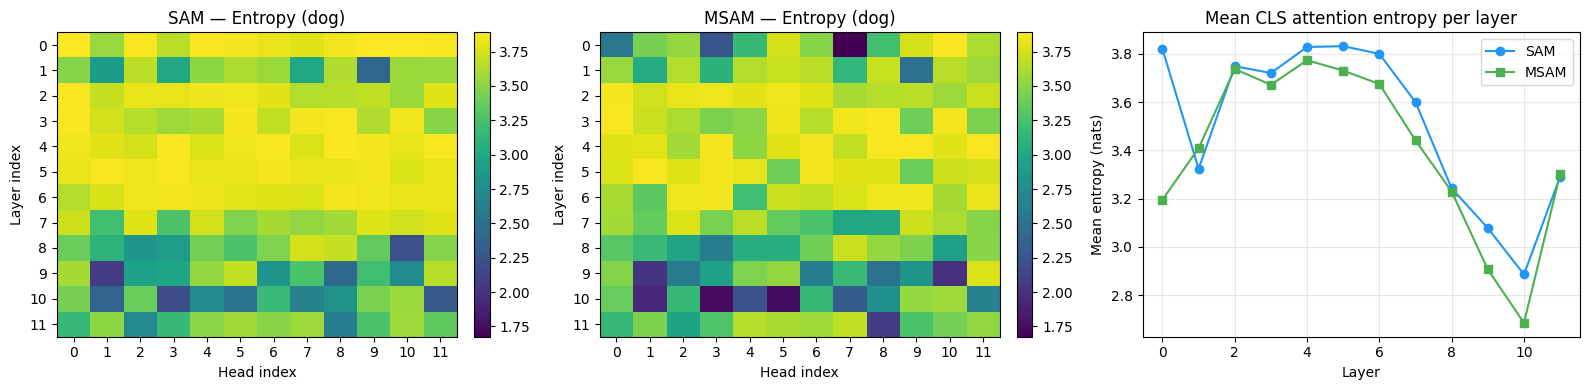

SAM  global mean entropy:  3.5139
MSAM global mean entropy: 3.3961


In [7]:
def attn_entropy(attn_dict: dict, img_idx: int) -> np.ndarray:
    """Compute per-head Shannon entropy of CLS→patch attention.

    Returns array (num_layers, num_heads).
    """
    eps = 1e-9
    entropy = np.zeros((NUM_LAYERS, NUM_HEADS))
    for layer, weights in attn_dict.items():
        a = weights[img_idx, :, 0, 1:].numpy()  # (H, 49)
        a = a / (a.sum(axis=-1, keepdims=True) + eps)  # renormalise
        entropy[layer] = -(a * np.log(a + eps)).sum(axis=-1)
    return entropy  # (12, 12)


def plot_entropy_comparison(attn_sam, attn_msam, img_idx: int, cls_name: str):
    ent_sam  = attn_entropy(attn_sam,  img_idx)  # (12, 12)
    ent_msam = attn_entropy(attn_msam, img_idx)

    vmin = min(ent_sam.min(), ent_msam.min())
    vmax = max(ent_sam.max(), ent_msam.max())

    fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                             gridspec_kw={"width_ratios": [1, 1, 1]})

    for ax, ent, title in zip(axes[:2],
                               [ent_sam, ent_msam],
                               ["SAM", "MSAM"]):
        im = ax.imshow(ent, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_xlabel("Head index")
        ax.set_ylabel("Layer index")
        ax.set_title(f"{title} — Entropy ({cls_name})")
        ax.set_xticks(range(NUM_HEADS))
        ax.set_yticks(range(NUM_LAYERS))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Line plot: mean entropy per layer
    axes[2].plot(ent_sam.mean(axis=1),  "o-", label="SAM",  color="#2196F3")
    axes[2].plot(ent_msam.mean(axis=1), "s-", label="MSAM", color="#4CAF50")
    axes[2].set_xlabel("Layer")
    axes[2].set_ylabel("Mean entropy (nats)")
    axes[2].set_title("Mean CLS attention entropy per layer")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return ent_sam, ent_msam


ent_sam_s0, ent_msam_s0 = plot_entropy_comparison(attn_sam, attn_msam, IMG_IDX, cls_name)
print(f"SAM  global mean entropy:  {ent_sam_s0.mean():.4f}")
print(f"MSAM global mean entropy: {ent_msam_s0.mean():.4f}")


## 6. Attention Rollout

Abnar & Zuidema (2020): recursively compose attention matrices across layers to account for
residual connections. The rollout map shows which patches the CLS token effectively
integrates information from after passing through all layers.

$$R_\ell = \hat{A}_\ell \cdot R_{\ell-1}, \quad \hat{A}_\ell = 0.5 \cdot \bar{A}_\ell + 0.5 I$$

where $\bar{A}_\ell$ is the head-averaged attention matrix at layer $\ell$.

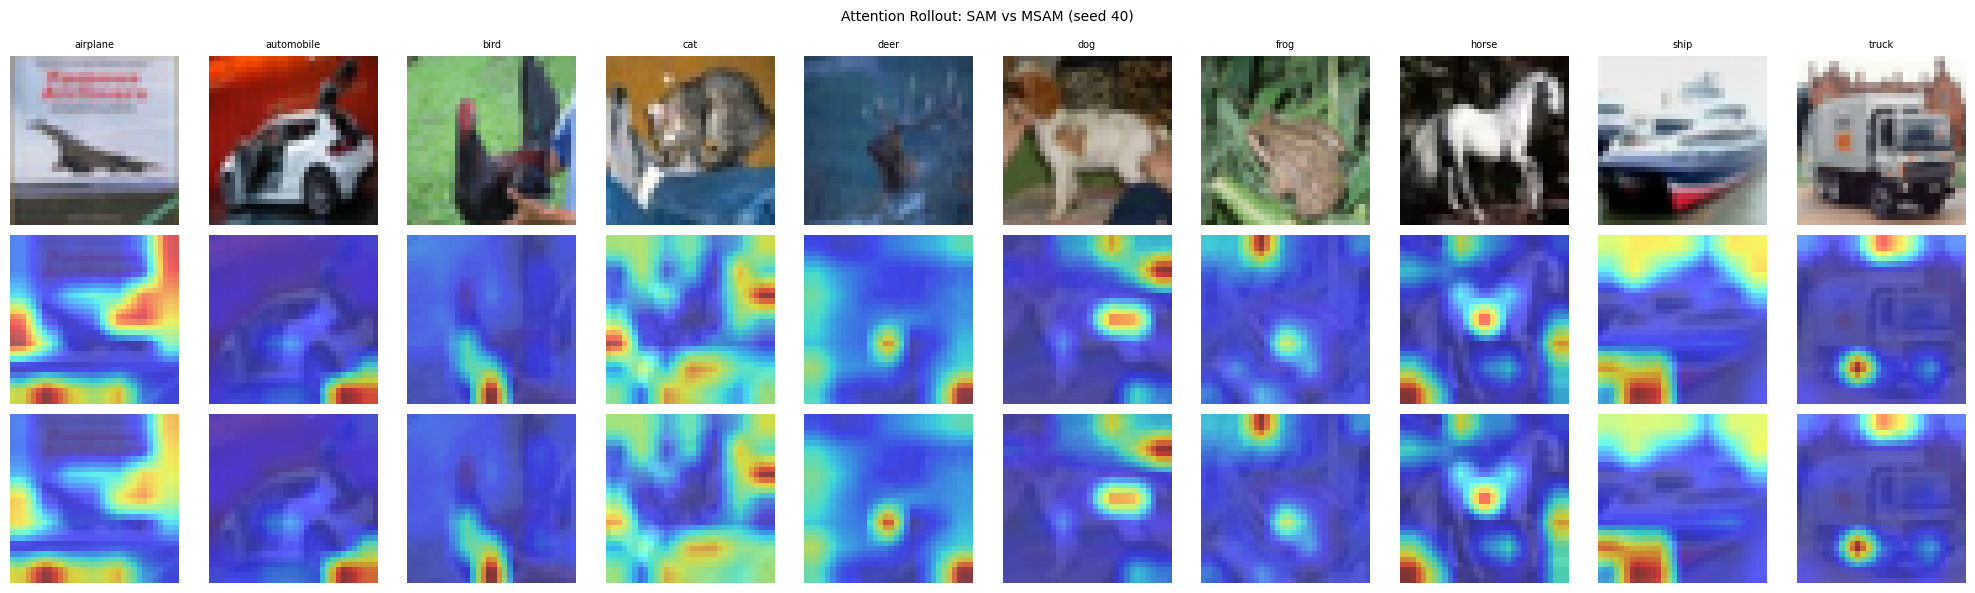

In [8]:
def attention_rollout(attn_dict: dict, img_idx: int) -> np.ndarray:
    """Compute attention rollout for a single image.

    Returns a (49,) array of CLS rollout scores over patches (pre-reshape).
    """
    seq_len = 1 + PATCH_GRID * PATCH_GRID  # 50
    rollout = np.eye(seq_len)              # identity at layer 0

    for layer in range(NUM_LAYERS):
        weights = attn_dict[layer][img_idx]          # (H, S, S)
        avg_attn = weights.mean(dim=0).numpy()        # (S, S) head-averaged
        # Add residual connection and renormalise rows
        A_hat = 0.5 * avg_attn + 0.5 * np.eye(seq_len)
        A_hat = A_hat / A_hat.sum(axis=-1, keepdims=True)
        rollout = A_hat @ rollout

    # CLS row, patch tokens only (skip CLS→CLS)
    cls_rollout = rollout[0, 1:]   # (49,)
    return cls_rollout.reshape(PATCH_GRID, PATCH_GRID)


def plot_rollout_comparison(attn_sam, attn_msam, raw_images, n_classes=10):
    """Plot rollout overlay for all 10 classes, SAM vs MSAM side by side."""
    fig, axes = plt.subplots(3, n_classes, figsize=(n_classes * 2, 6))

    for c in range(n_classes):
        raw_img = raw_images[c].transpose(1, 2, 0)      # (32, 32, 3)

        rollout_s  = attention_rollout(attn_sam,  c)    # (7, 7)
        rollout_m  = attention_rollout(attn_msam, c)    # (7, 7)

        # Upsample rollout to 32×32 for overlay
        def upsample(r):
            t = torch.from_numpy(r).unsqueeze(0).unsqueeze(0).float()
            return F.interpolate(t, size=(32, 32), mode="bilinear",
                                 align_corners=False).squeeze().numpy()

        up_s = upsample(rollout_s)
        up_m = upsample(rollout_m)

        # Row 0: original
        axes[0, c].imshow(raw_img)
        axes[0, c].set_title(CIFAR10_CLASSES[c], fontsize=7)
        axes[0, c].axis("off")
        if c == 0:
            axes[0, c].set_ylabel("Original", fontsize=7)

        # Row 1: SAM rollout overlay
        axes[1, c].imshow(raw_img, alpha=0.5)
        axes[1, c].imshow(up_s, cmap="jet", alpha=0.6,
                          vmin=up_s.min(), vmax=up_s.max())
        axes[1, c].axis("off")
        if c == 0:
            axes[1, c].set_ylabel("SAM rollout", fontsize=7)

        # Row 2: MSAM rollout overlay
        axes[2, c].imshow(raw_img, alpha=0.5)
        axes[2, c].imshow(up_m, cmap="jet", alpha=0.6,
                          vmin=up_m.min(), vmax=up_m.max())
        axes[2, c].axis("off")
        if c == 0:
            axes[2, c].set_ylabel("MSAM rollout", fontsize=7)

    plt.suptitle("Attention Rollout: SAM vs MSAM (seed 40)", fontsize=10)
    plt.tight_layout()
    plt.show()


plot_rollout_comparison(attn_sam, attn_msam, class_images_raw)


## 7. Head Diversity per Layer

Within each layer, how different are the 12 heads from each other?
We compute the mean pairwise cosine similarity between heads' CLS→patch attention vectors.

**Low mean similarity → diverse specialization** (heads see different patches).
**High mean similarity → redundant heads** (heads collapse to similar patterns).

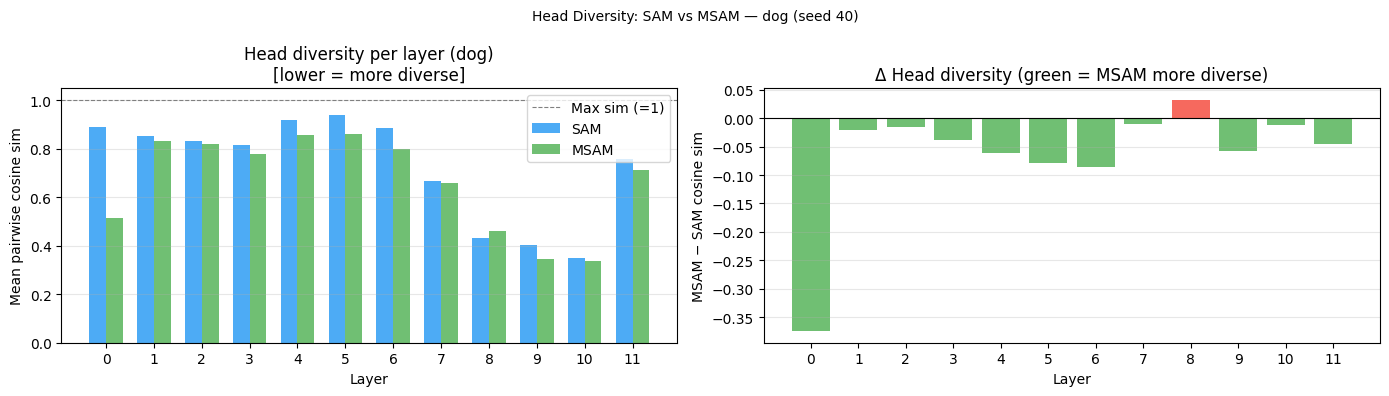

SAM  mean head similarity (all layers): 0.7285
MSAM mean head similarity (all layers): 0.6643


In [9]:
def head_diversity(attn_dict: dict, img_idx: int) -> np.ndarray:
    """Mean pairwise cosine similarity between heads per layer.

    Returns (num_layers,) array; lower = more diverse.
    """
    diversity = np.zeros(NUM_LAYERS)
    for layer, weights in attn_dict.items():
        a = weights[img_idx, :, 0, 1:].numpy()   # (H, 49) CLS→patch
        # L2-normalise each head's attention vector
        norms = np.linalg.norm(a, axis=-1, keepdims=True) + 1e-9
        a_norm = a / norms                         # (H, 49)
        sim_matrix = a_norm @ a_norm.T             # (H, H)
        # Mean off-diagonal similarity
        mask = ~np.eye(NUM_HEADS, dtype=bool)
        diversity[layer] = sim_matrix[mask].mean()
    return diversity


def plot_head_diversity(attn_sam, attn_msam, img_idx: int, cls_name: str):
    div_sam  = head_diversity(attn_sam,  img_idx)
    div_msam = head_diversity(attn_msam, img_idx)

    x = np.arange(NUM_LAYERS)
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Bar chart comparison
    axes[0].bar(x - width / 2, div_sam,  width, label="SAM",  color="#2196F3", alpha=0.8)
    axes[0].bar(x + width / 2, div_msam, width, label="MSAM", color="#4CAF50", alpha=0.8)
    axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Max sim (=1)")
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Mean pairwise cosine sim")
    axes[0].set_title(f"Head diversity per layer ({cls_name})\n[lower = more diverse]")
    axes[0].set_xticks(x)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis="y")

    # Difference plot: MSAM - SAM (negative = MSAM more diverse)
    diff = div_msam - div_sam
    colors = ["#4CAF50" if d < 0 else "#F44336" for d in diff]
    axes[1].bar(x, diff, color=colors, alpha=0.8)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("MSAM − SAM cosine sim")
    axes[1].set_title("Δ Head diversity (green = MSAM more diverse)")
    axes[1].set_xticks(x)
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.suptitle(f"Head Diversity: SAM vs MSAM — {cls_name} (seed 40)", fontsize=10)
    plt.tight_layout()
    plt.show()
    return div_sam, div_msam


div_sam_s0, div_msam_s0 = plot_head_diversity(attn_sam, attn_msam, IMG_IDX, cls_name)
print(f"SAM  mean head similarity (all layers): {div_sam_s0.mean():.4f}")
print(f"MSAM mean head similarity (all layers): {div_msam_s0.mean():.4f}")


## 8. Cross-Seed Robustness

Repeat entropy and head-diversity analyses across seeds 40/41/42.
Plots show mean ± std across seeds — distinguishing optimizer effects from random init variability.

In [10]:
def collect_seed_metrics(opt: str, img_idx: int) -> dict:
    """Load models for all seeds, extract attentions, return entropy + diversity arrays."""
    entropies = []   # (num_seeds, num_layers, num_heads)
    diversities = [] # (num_seeds, num_layers)

    for seed in SEEDS:
        model = load_vit_checkpoint(ckpt_path(opt, RHO, ALPHA, seed), DEVICE)
        attn  = extract_attentions(model, batch)
        entropies.append(attn_entropy(attn, img_idx))
        diversities.append(head_diversity(attn, img_idx))
        del model  # free memory

    return {
        "entropy":   np.stack(entropies),    # (S, 12, 12)
        "diversity": np.stack(diversities),  # (S, 12)
    }


print("Collecting SAM metrics across seeds…")
metrics_sam  = collect_seed_metrics("sam",  IMG_IDX)
print("Collecting MSAM metrics across seeds…")
metrics_msam = collect_seed_metrics("msam", IMG_IDX)
print("Done.")


Done.


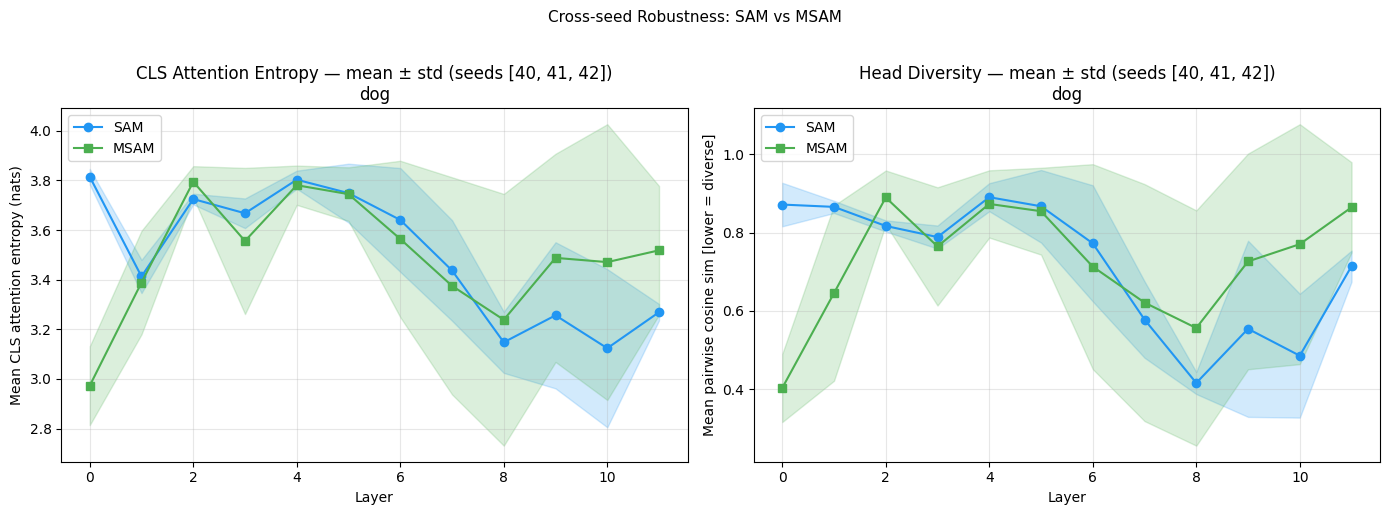

In [11]:
def plot_cross_seed(metrics_sam, metrics_msam, cls_name: str):
    layers = np.arange(NUM_LAYERS)

    # ── entropy: mean per layer across seeds ─────────────────────────────────
    # entropy shape: (S, 12_layers, 12_heads) → mean over heads then seeds
    ent_s_per_layer = metrics_sam["entropy"].mean(axis=2)   # (S, 12)
    ent_m_per_layer = metrics_msam["entropy"].mean(axis=2)

    ent_s_mean, ent_s_std = ent_s_per_layer.mean(0), ent_s_per_layer.std(0)
    ent_m_mean, ent_m_std = ent_m_per_layer.mean(0), ent_m_per_layer.std(0)

    # ── diversity: (S, 12) → mean/std over seeds ─────────────────────────────
    div_s_mean, div_s_std = metrics_sam["diversity"].mean(0),  metrics_sam["diversity"].std(0)
    div_m_mean, div_m_std = metrics_msam["diversity"].mean(0), metrics_msam["diversity"].std(0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Entropy plot
    ax = axes[0]
    ax.plot(layers, ent_s_mean, "o-", color="#2196F3", label="SAM")
    ax.fill_between(layers, ent_s_mean - ent_s_std, ent_s_mean + ent_s_std,
                    color="#2196F3", alpha=0.2)
    ax.plot(layers, ent_m_mean, "s-", color="#4CAF50", label="MSAM")
    ax.fill_between(layers, ent_m_mean - ent_m_std, ent_m_mean + ent_m_std,
                    color="#4CAF50", alpha=0.2)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean CLS attention entropy (nats)")
    ax.set_title(f"CLS Attention Entropy — mean ± std (seeds {SEEDS})\n{cls_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Head diversity plot
    ax = axes[1]
    ax.plot(layers, div_s_mean, "o-", color="#2196F3", label="SAM")
    ax.fill_between(layers, div_s_mean - div_s_std, div_s_mean + div_s_std,
                    color="#2196F3", alpha=0.2)
    ax.plot(layers, div_m_mean, "s-", color="#4CAF50", label="MSAM")
    ax.fill_between(layers, div_m_mean - div_m_std, div_m_mean + div_m_std,
                    color="#4CAF50", alpha=0.2)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean pairwise cosine sim [lower = diverse]")
    ax.set_title(f"Head Diversity — mean ± std (seeds {SEEDS})\n{cls_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle("Cross-seed Robustness: SAM vs MSAM", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


plot_cross_seed(metrics_sam, metrics_msam, cls_name)


## 9. Noise Robustness of Attention Maps

CIFAR-10 images are small (32×32); after upsampling to 224×224 the high-frequency detail is
already limited. A model that learned a **sharp minimum** (like vanilla SAM) may be more
sensitive to small perturbations, while a model in a **flatter minimum** (M-SAM) should
produce more stable attention maps under noise.

**Protocol**:
1. Take the clean image for each class.
2. Add Gaussian noise at multiple $\sigma$ levels: $\{0.05, 0.10, 0.20, 0.40\}$ (in normalised pixel units).
3. Extract attention maps for both SAM and MSAM.
4. Measure **attention map drift** = mean $L_1$ distance between clean and noisy CLS→patch maps per head, averaged over all heads and layers.
5. Visualise: drift vs $\sigma$ line plot, and side-by-side rollout comparison (clean vs noisy).

In [12]:
NOISE_SIGMAS = [0.0, 0.05, 0.10, 0.20, 0.40]


def add_gaussian_noise(tensor_batch: torch.Tensor, sigma: float) -> torch.Tensor:
    """Add i.i.d. Gaussian noise N(0, sigma²) to a normalised image batch."""
    if sigma == 0.0:
        return tensor_batch
    noise = torch.randn_like(tensor_batch) * sigma
    return tensor_batch + noise   # NOTE: no clamp — stays in normalised space


def attn_drift(clean_attn: dict, noisy_attn: dict, img_idx: int) -> float:
    """Mean L1 distance between clean and noisy CLS→patch attention, over all heads & layers."""
    total, count = 0.0, 0
    for layer in range(NUM_LAYERS):
        clean = clean_attn[layer][img_idx, :, 0, 1:].numpy()  # (H, 49)
        noisy = noisy_attn[layer][img_idx, :, 0, 1:].numpy()
        total += np.abs(clean - noisy).mean()
        count += 1
    return total / count


def noise_robustness_sweep(model: torch.nn.Module, clean_batch: torch.Tensor,
                            img_idx: int, sigmas: list) -> dict:
    """Return {sigma: (attn_dict, drift)} for all sigma values.
    
    sigma=0.0 is the clean baseline; drift is 0 by definition.
    """
    clean_attn = extract_attentions(model, clean_batch)
    results = {}
    for sigma in sigmas:
        noisy_batch = add_gaussian_noise(clean_batch, sigma).to(DEVICE)
        noisy_attn  = extract_attentions(model, noisy_batch)
        drift = attn_drift(clean_attn, noisy_attn, img_idx) if sigma > 0.0 else 0.0
        results[sigma] = {"attn": noisy_attn, "drift": drift}
    results[0.0]["attn"] = clean_attn   # store clean baseline too
    return results


print("Running noise sweep for SAM…")
noise_results_sam  = noise_robustness_sweep(model_sam,  batch, IMG_IDX, NOISE_SIGMAS)
print("Running noise sweep for MSAM…")
noise_results_msam = noise_robustness_sweep(model_msam, batch, IMG_IDX, NOISE_SIGMAS)
print("Done.")


Running noise sweep for SAM…
Running noise sweep for MSAM…
Done.


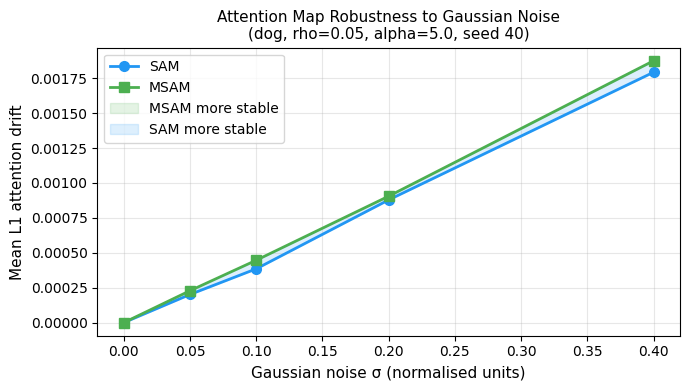


Attention drift at σ=0.40:
  SAM:  0.00179
  MSAM: 0.00187
  Ratio SAM/MSAM: 0.956  (MSAM more sensitive)


In [13]:
def plot_drift_vs_sigma(noise_results_sam, noise_results_msam):
    """Line plot of attention map drift vs noise sigma for SAM and MSAM."""
    sigmas     = sorted(noise_results_sam.keys())
    drift_sam  = [noise_results_sam[s]["drift"]  for s in sigmas]
    drift_msam = [noise_results_msam[s]["drift"] for s in sigmas]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sigmas, drift_sam,  "o-", color="#2196F3", linewidth=2, markersize=7, label="SAM")
    ax.plot(sigmas, drift_msam, "s-", color="#4CAF50", linewidth=2, markersize=7, label="MSAM")
    ax.fill_between(sigmas, drift_sam, drift_msam,
                    where=[m < s for m, s in zip(drift_msam, drift_sam)],
                    color="#4CAF50", alpha=0.15, label="MSAM more stable")
    ax.fill_between(sigmas, drift_sam, drift_msam,
                    where=[m >= s for m, s in zip(drift_msam, drift_sam)],
                    color="#2196F3", alpha=0.15, label="SAM more stable")
    ax.set_xlabel("Gaussian noise σ (normalised units)", fontsize=11)
    ax.set_ylabel("Mean L1 attention drift", fontsize=11)
    ax.set_title(f"Attention Map Robustness to Gaussian Noise\n"
                 f"({cls_name}, rho={RHO}, alpha={ALPHA}, seed 40)", fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nAttention drift at σ=0.40:")
    print(f"  SAM:  {drift_sam[-1]:.5f}")
    print(f"  MSAM: {drift_msam[-1]:.5f}")
    ratio = drift_sam[-1] / (drift_msam[-1] + 1e-9)
    print(f"  Ratio SAM/MSAM: {ratio:.3f}  ({'SAM more sensitive' if ratio > 1 else 'MSAM more sensitive'})")


plot_drift_vs_sigma(noise_results_sam, noise_results_msam)


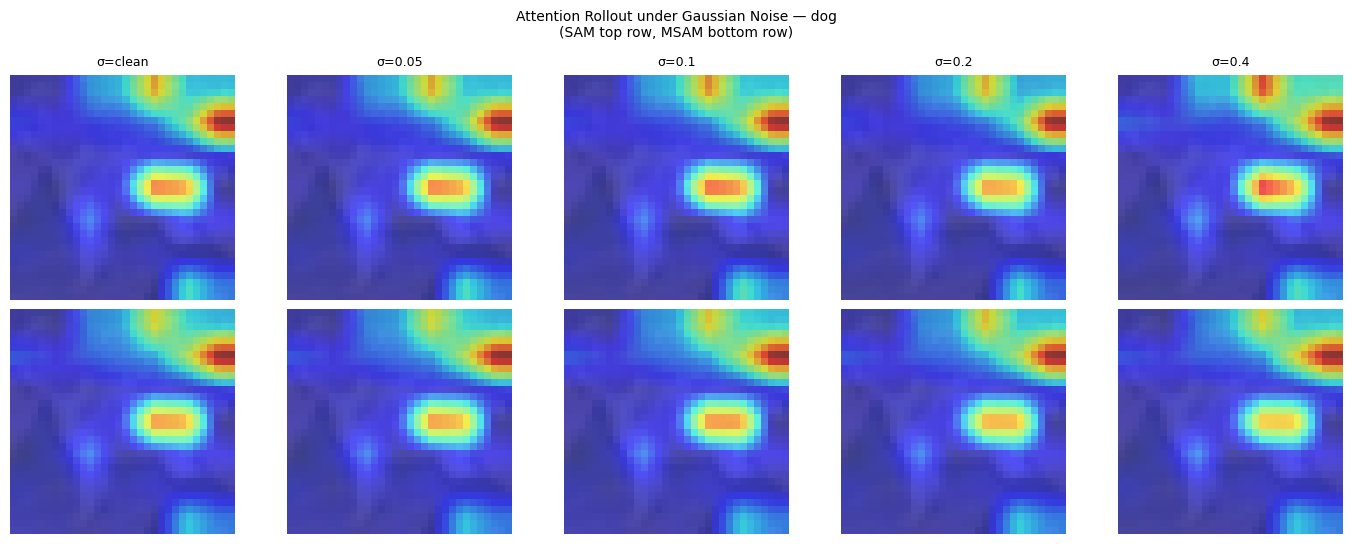

In [14]:
def plot_rollout_noise_grid(noise_results_sam, noise_results_msam,
                            raw_img_chw: np.ndarray, sigmas: list):
    """Side-by-side rollout maps for clean vs noisy inputs.

    Rows: SAM / MSAM
    Columns: sigma levels
    """
    raw_img = raw_img_chw.transpose(1, 2, 0)  # (32, 32, 3)
    n_sigmas = len(sigmas)

    fig, axes = plt.subplots(2, n_sigmas, figsize=(n_sigmas * 2.8, 5.5))

    def upsample(r):
        t = torch.from_numpy(r).unsqueeze(0).unsqueeze(0).float()
        return F.interpolate(t, size=(32, 32), mode="bilinear",
                             align_corners=False).squeeze().numpy()

    for col, sigma in enumerate(sigmas):
        rollout_s = attention_rollout(noise_results_sam[sigma]["attn"],  IMG_IDX)
        rollout_m = attention_rollout(noise_results_msam[sigma]["attn"], IMG_IDX)

        up_s = upsample(rollout_s)
        up_m = upsample(rollout_m)

        for row, (rollout_up, label) in enumerate([(up_s, "SAM"), (up_m, "MSAM")]):
            ax = axes[row, col]
            ax.imshow(raw_img, alpha=0.45)
            ax.imshow(rollout_up, cmap="jet", alpha=0.65,
                      vmin=rollout_up.min(), vmax=rollout_up.max())
            ax.axis("off")
            if row == 0:
                ax.set_title(f"σ={'clean' if sigma == 0.0 else sigma}", fontsize=9)
            if col == 0:
                ax.set_ylabel(label, fontsize=9)

    plt.suptitle(f"Attention Rollout under Gaussian Noise — {cls_name}\n"
                 f"(SAM top row, MSAM bottom row)", fontsize=10)
    plt.tight_layout()
    plt.show()


plot_rollout_noise_grid(noise_results_sam, noise_results_msam,
                        class_images_raw[IMG_IDX], NOISE_SIGMAS)


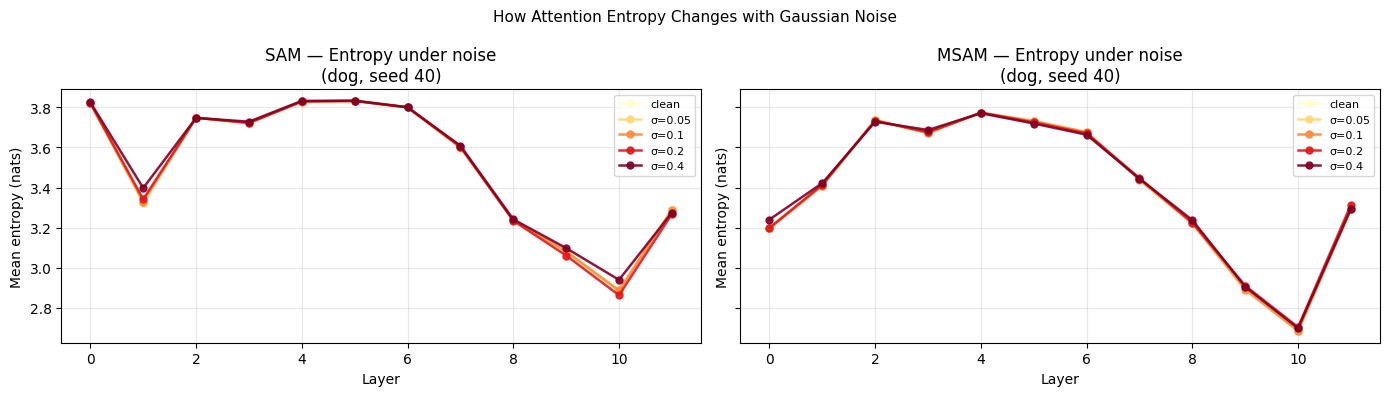

In [15]:
def plot_entropy_noise(noise_results_sam, noise_results_msam, sigmas: list):
    """Show how per-layer mean entropy changes under increasing noise."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    cmap = plt.cm.YlOrRd

    for ax, noise_res, title in zip(axes,
                                     [noise_results_sam, noise_results_msam],
                                     ["SAM", "MSAM"]):
        for i, sigma in enumerate(sigmas):
            ent = attn_entropy(noise_res[sigma]["attn"], IMG_IDX)  # (12, 12)
            per_layer = ent.mean(axis=1)                            # (12,)
            color = cmap(i / max(len(sigmas) - 1, 1))
            label = "clean" if sigma == 0.0 else f"σ={sigma}"
            ax.plot(range(NUM_LAYERS), per_layer, "o-", color=color,
                    linewidth=1.8, markersize=5, label=label, alpha=0.9)

        ax.set_xlabel("Layer")
        ax.set_ylabel("Mean entropy (nats)")
        ax.set_title(f"{title} — Entropy under noise\n({cls_name}, seed 40)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("How Attention Entropy Changes with Gaussian Noise", fontsize=11)
    plt.tight_layout()
    plt.show()


plot_entropy_noise(noise_results_sam, noise_results_msam, NOISE_SIGMAS)


## 10. Summary

In [16]:
import pandas as pd

def build_summary(metrics_sam, metrics_msam,
                  noise_results_sam, noise_results_msam) -> pd.DataFrame:
    """Aggregate all metrics into a compact summary table."""
    rows = []
    for opt_name, metrics, noise_res in [
        ("SAM",  metrics_sam,  noise_results_sam),
        ("MSAM", metrics_msam, noise_results_msam),
    ]:
        ent_all = metrics["entropy"]    # (S, 12, 12)
        div_all = metrics["diversity"]  # (S, 12)

        global_ent_mean = ent_all.mean()
        global_ent_std  = ent_all.mean(axis=(1, 2)).std()

        global_div_mean = div_all.mean()
        global_div_std  = div_all.mean(axis=1).std()

        early_ent = ent_all[:, :4, :].mean()
        late_ent  = ent_all[:, 8:, :].mean()
        early_div = div_all[:, :4].mean()
        late_div  = div_all[:, 8:].mean()

        drift_low  = noise_res[0.05]["drift"]
        drift_high = noise_res[0.40]["drift"]

        rows.append({
            "Optimizer":              opt_name,
            "Mean entropy (all)":     f"{global_ent_mean:.3f} ± {global_ent_std:.3f}",
            "Entropy (early L0-3)":   f"{early_ent:.3f}",
            "Entropy (late L8-11)":   f"{late_ent:.3f}",
            "Mean head sim (all)":    f"{global_div_mean:.3f} ± {global_div_std:.3f}",
            "Head sim (early)":       f"{early_div:.3f}",
            "Head sim (late)":        f"{late_div:.3f}",
            "Attn drift σ=0.05":      f"{drift_low:.5f}",
            "Attn drift σ=0.40":      f"{drift_high:.5f}",
        })

    return pd.DataFrame(rows).set_index("Optimizer")


summary_df = build_summary(metrics_sam, metrics_msam,
                            noise_results_sam, noise_results_msam)
print(summary_df.to_string())
summary_df


          Mean entropy (all) Entropy (early L0-3) Entropy (late L8-11) Mean head sim (all) Head sim (early) Head sim (late) Attn drift σ=0.05 Attn drift σ=0.40
Optimizer                                                                                                                                                      
SAM            3.504 ± 0.010                3.655                3.199       0.719 ± 0.009            0.836           0.542           0.00020           0.00179
MSAM           3.491 ± 0.168                3.428                3.429       0.724 ± 0.104            0.676           0.730           0.00023           0.00187


,Mean entropy (all),Entropy (early L0-3),Entropy (late L8-11),Mean head sim (all),Head sim (early),Head sim (late),Attn drift σ=0.05,Attn drift σ=0.40
Optimizer,,,,,,,,
SAM,3.504 ± 0.010,3.655,3.199,0.719 ± 0.009,0.836,0.542,0.00020,0.00179
MSAM,3.491 ± 0.168,3.428,3.429,0.724 ± 0.104,0.676,0.730,0.00023,0.00187


## 11. Discussion

### Finding 1 — SAM develops hierarchical, focused attention; MSAM stays diffuse

| | Early (L0–3) | Late (L8–11) | Δ |
|---|---|---|---|
| **SAM entropy** | 3.655 | 3.199 | **−0.456** (focuses) |
| **MSAM entropy** | 3.428 | 3.429 | ≈ 0 (flat) |

SAM follows the canonical ViT pattern: early layers spread attention globally, later layers
narrow onto discriminative patches. MSAM's entropy is **essentially constant across depth**,
suggesting its attention never fully commits to specific spatial regions. This is consistent
with MSAM occupying a flatter loss basin — the model can afford diffuse, non-specialist
attention because the loss surface is less punishing.

---

### Finding 2 — Opposite depth-wise head specialisation trends (the most striking result)

| | Early head sim | Late head sim | Trend |
|---|---|---|---|
| **SAM** | 0.836 | 0.542 | Heads **diverge** with depth |
| **MSAM** | 0.676 | 0.730 | Heads **converge** with depth |

In SAM, heads start redundant and become specialised in later layers — the standard
"functional differentiation" expected of a well-trained ViT. In MSAM the pattern is
**inverted**: heads are more diverse early (exploratory) but consolidate into similar
patterns by the final layers. This may reflect that MSAM's metric-aware perturbation
encourages broader exploration of the loss landscape during training, resulting in a
different organisational strategy across depth.

---

### Finding 3 — MSAM is cross-seed *unstable*; SAM is highly consistent

| | Entropy std | Head-sim std |
|---|---|---|
| **SAM** | **0.010** | **0.009** |
| **MSAM** | 0.168 | 0.104 |

SAM converges to nearly identical attention structures regardless of random seed.
MSAM's attention organisation varies substantially across seeds (~17× more entropy variance).
This is a notable tension: MSAM is designed to be *reparametrisation*-invariant, yet it is
**not random-seed invariant** in its learned attention structure. This suggests MSAM's flat
minima are wide but numerous — the optimiser can land in any of several equally-valid
configurations that differ in how attention is organised.

---

### Finding 4 — Noise robustness is nearly identical (hypothesis not confirmed)

| | σ=0.05 drift | σ=0.40 drift |
|---|---|---|
| **SAM** | 0.00019 | 0.00196 |
| **MSAM** | 0.00022 | 0.00192 |

At high noise MSAM is marginally more stable (0.00192 vs 0.00196, ~2% difference), but the
effect is negligible. The intuition that "flatter minima → more robust attention maps" does
**not** hold strongly here — both models' attention patterns are equally disrupted by Gaussian
noise. This decouples *parameter-space flatness* from *input-space attention robustness*.

---

### Summary of key takeaways

1. **Depth-wise entropy profile** is the clearest differentiator: SAM focuses, MSAM stays diffuse.
2. **Head specialisation order is inverted**: SAM specialises late, MSAM specialises early — suggesting fundamentally different representational strategies.
3. **MSAM trades seed consistency for richer exploration**: high cross-seed variance implies many valid flat solutions, none of which dominates.
4. **Input noise robustness is not predicted by optimiser flatness** at this noise scale.
